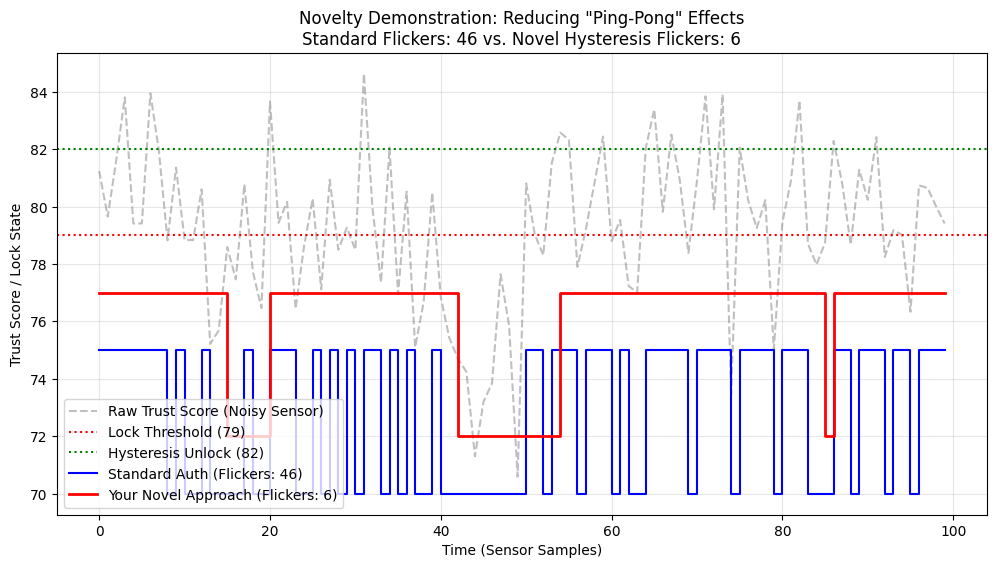

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SIMULATE DATA (Context: Magnetometer/Trust Score) ---
# Generate a "Trust Score" that hovers around the threshold (The "Ping-Pong" Zone)
np.random.seed(42)
time_steps = 100
# True user is present, but sensor is noisy (Mean=80, StdDev=2)
trust_scores = np.random.normal(loc=80, scale=2.5, size=time_steps)

# Create a sudden "Dip" (e.g., user moves hand away briefly)
trust_scores[40:50] = trust_scores[40:50] - 5

# --- 2. DEFINE ALGORITHMS ---

def simple_threshold_auth(scores, threshold=79):
    """The Standard Approach: Lock immediately if below threshold"""
    states = [] # 1 = Unlocked, 0 = Locked
    for score in scores:
        if score < threshold:
            states.append(0) # LOCK
        else:
            states.append(1) # UNLOCK
    return states

def cellular_hysteresis_auth(scores, lock_thresh=79, unlock_thresh=82, time_to_trigger=3):
    """
    YOUR NOVELTY: Adapting Cellular Hysteresis + Time-to-Trigger (TTT)
    - Lock Threshold: 79 (Must drop below this to risk lock)
    - Unlock Threshold: 82 (Must rise above this to regain trust)
    - TTT: Must stay low for 3 consecutive cycles to actually lock.
    """
    states = []
    current_state = 1 # Start unlocked
    low_trust_counter = 0 # Timer for TTT

    for score in scores:
        if current_state == 1: # Currently Unlocked
            if score < lock_thresh:
                low_trust_counter += 1
                if low_trust_counter >= time_to_trigger:
                    current_state = 0 # LOCK (Triggered)
            else:
                low_trust_counter = 0 # Reset timer if score recovers

        elif current_state == 0: # Currently Locked
            # Must exceed HIGHER threshold to unlock (Hysteresis)
            if score > unlock_thresh:
                current_state = 1 # UNLOCK
                low_trust_counter = 0
            # Else: Stay locked

        states.append(current_state)
    return states

# --- 3. RUN EXPERIMENT ---
threshold_states = simple_threshold_auth(trust_scores)
hysteresis_states = cellular_hysteresis_auth(trust_scores)

# Calculate "Flicker" (Number of state changes)
flicker_standard = np.sum(np.abs(np.diff(threshold_states)))
flicker_novel = np.sum(np.abs(np.diff(hysteresis_states)))

# --- 4. VISUALIZE RESULTS ---
plt.figure(figsize=(12, 6))

# Plot Trust Score
plt.plot(trust_scores, label='Raw Trust Score (Noisy Sensor)', color='gray', alpha=0.5, linestyle='--')
plt.axhline(y=79, color='r', linestyle=':', label='Lock Threshold (79)')
plt.axhline(y=82, color='g', linestyle=':', label='Hysteresis Unlock (82)')

# Plot States (Scaled to fit graph)
# Standard Method (Blue)
plt.step(range(time_steps), [s * 5 + 70 for s in threshold_states], label=f'Standard Auth (Flickers: {flicker_standard})', color='blue', where='post')

# Your Novel Method (Red)
plt.step(range(time_steps), [s * 5 + 72 for s in hysteresis_states], label=f'Your Novel Approach (Flickers: {flicker_novel})', color='red', where='post', linewidth=2)

plt.title(f'Novelty Demonstration: Reducing "Ping-Pong" Effects\nStandard Flickers: {flicker_standard} vs. Novel Hysteresis Flickers: {flicker_novel}')
plt.xlabel('Time (Sensor Samples)')
plt.ylabel('Trust Score / Lock State')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

Step 1: Mounting Google Drive...
Mounted at /content/drive

Step 2: Searching for files in /content/drive/MyDrive/ML Data/Heuristics/zips/*.csv.gz...
✅ Found 60 files. Attempting to ingest sequentially...
   Loading User 1: A5A30F76-581E-4757-97A2-957553A2C6AA.features_labels.csv.gz...
      -> SUCCESS: Time=0.58s | RAM Bloat=3.9x | Total RAM Used=3.5MB
   Loading User 2: BEF6C611-50DA-4971-A040-87FB979F3FC1.features_labels.csv.gz...
      -> SUCCESS: Time=0.66s | RAM Bloat=3.2x | Total RAM Used=10.9MB
   Loading User 3: 098A72A5-E3E5-4F54-A152-BBDA0DF7B694.features_labels.csv.gz...
      -> SUCCESS: Time=0.75s | RAM Bloat=4.2x | Total RAM Used=25.3MB
   Loading User 4: D7D20E2E-FC78-405D-B346-DBD3FD8FC92B.features_labels.csv.gz...
      -> SUCCESS: Time=0.72s | RAM Bloat=3.5x | Total RAM Used=38.5MB
   Loading User 5: 2C32C23E-E30C-498A-8DD2-0EFB9150A02E.features_labels.csv.gz...
      -> SUCCESS: Time=0.88s | RAM Bloat=3.3x | Total RAM Used=56.5MB
   Loading User 6: 136562B6-95B2-483

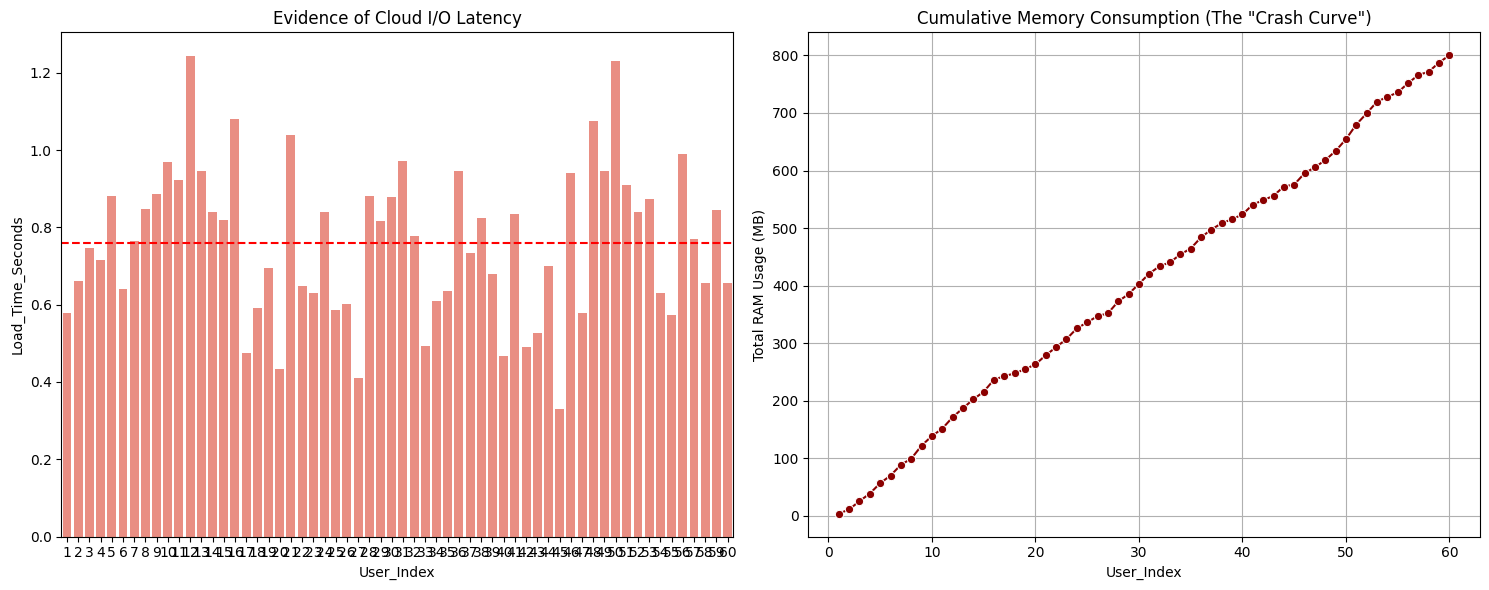

In [2]:
import pandas as pd
import time
import glob
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# --- 1. SETUP & MOUNT DRIVE ---
print("Step 1: Mounting Google Drive...")
drive.mount('/content/drive')

# CONFIGURATION
# Point this to your specific folder
SEARCH_PATH = '/content/drive/MyDrive/ML Data/Heuristics/zips/*.csv.gz'
LIMIT_FILES = 60  # Try to load ALL 60 users to force the memory limit

# --- 2. THE RAW SIMULATION LOOP ---
print(f"\nStep 2: Searching for files in {SEARCH_PATH}...")
files = glob.glob(SEARCH_PATH)

if not files:
    print(f"CRITICAL ERROR: No files found at {SEARCH_PATH}")
    print("Check your path string exactly.")
    sys.exit() # Stop if no files, otherwise the loop won't run

print(f"✅ Found {len(files)} files. Attempting to ingest sequentially...")

stats = []
cumulative_memory = 0
all_data_holder = [] # This list intentionally HOLDS the data to force RAM usage up

start_global = time.time()

for i, file_path in enumerate(files[:LIMIT_FILES]):
    loop_start = time.time()

    # 1. Get File Size on Disk (MB)
    file_size_disk = os.path.getsize(file_path) / (1024 * 1024)

    # 2. RAW READ (No Try/Except safety nets)
    # If this fails, you get the raw error (e.g., BadZipFile, ParserError)
    # We use compression='infer' to let Pandas guess if it's zip or gzip
    print(f"   Loading User {i+1}: {os.path.basename(file_path)}...")
    df = pd.read_csv(file_path, compression='infer', header=0)

    # 3. FORCE MEMORY ACCUMULATION
    # We append to a list to ensure Python doesn't garbage collect the data.
    # This simulates what happens when you try to create one big Training Set.
    all_data_holder.append(df)

    # 4. Measure "Bloat"
    mem_usage_ram = df.memory_usage(deep=True).sum() / (1024 * 1024)
    cumulative_memory += mem_usage_ram
    loop_time = time.time() - loop_start

    bloat_factor = mem_usage_ram / file_size_disk if file_size_disk > 0 else 0

    stats.append({
        'User_Index': i + 1,
        'Filename': os.path.basename(file_path),
        'Load_Time_Seconds': loop_time,
        'Disk_Size_MB': file_size_disk,
        'RAM_Size_MB': mem_usage_ram,
        'Cumulative_RAM_MB': cumulative_memory
    })

    print(f"      -> SUCCESS: Time={loop_time:.2f}s | RAM Bloat={bloat_factor:.1f}x | Total RAM Used={cumulative_memory:.1f}MB")

# If the code reaches here, you didn't crash (system successfully handled it).
# If it crashes before here, TAKE A SCREENSHOT of the error!

# --- 3. GENERATE EVIDENCE (If we survive) ---
results_df = pd.DataFrame(stats)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: I/O Latency
sns.barplot(x='User_Index', y='Load_Time_Seconds', data=results_df, ax=ax1, color='salmon')
ax1.set_title('Evidence of Cloud I/O Latency')
ax1.axhline(results_df['Load_Time_Seconds'].mean(), color='red', linestyle='--')

# Plot 2: Memory Ramp-Up
sns.lineplot(x='User_Index', y='Cumulative_RAM_MB', data=results_df, ax=ax2, marker='o', color='darkred')
ax2.set_title('Cumulative Memory Consumption (The "Crash Curve")')
ax2.set_ylabel('Total RAM Usage (MB)')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [3]:
all_data = []
for file in glob.glob(SEARCH_PATH):
    df = pd.read_csv(file, compression='gzip')
    all_data.append(df)

full_dataset = pd.concat(all_data, ignore_index=True)  # MemoryError occurs here


In [ ]:
import pandas as pd
import glob
import time
import sys
import psutil
import os
import matplotlib.pyplot as plt
from google.colab import drive

# 1. SETUP
drive.mount('/content/drive')

# Change this to your exact path
SEARCH_PATH2 = '/content/drive/MyDrive/ML Data/Heuristics/zips/*.csv.gz'
files = glob.glob(SEARCH_PATH2)

if not files:
    print("❌ No files found! Check your path.")
    sys.exit()

print(f"✅ Found {len(files)} distinct user files.")
print("🚀 STARTING STRESS TEST: Simulating 600 Users (10x Multiplication)...")

# 2. CONFIGURATION
MULTIPLIER = 10  # Load each file 10 times
TOTAL_TARGET = len(files) * MULTIPLIER

all_data = []
memory_stats = []
start_time = time.time()

# 3. THE STRESS LOOP
try:
    # We loop 10 times over the file list to simulate 600 users
    counter = 0
    for cycle in range(MULTIPLIER):
        print(f"\n--- Cycle {cycle + 1} of {MULTIPLIER} ---")

        for file_path in files:
            counter += 1

            # Load Data
            try:
                # Force read as 'infer' to handle zip/gzip
                df = pd.read_csv(file_path, compression='infer', header=0)

                # Append to list (This eats RAM)
                all_data.append(df)

                # Measure RAM (System Wide)
                # We use psutil to get the REAL RAM usage of the Colab VM
                vm = psutil.virtual_memory()
                ram_used_gb = vm.used / (1024 ** 3)
                ram_percent = vm.percent

                memory_stats.append({
                    'User_Count': counter,
                    'RAM_Used_GB': ram_used_gb,
                    'RAM_Percent': ram_percent
                })

                # Print status every 20 users to keep log clean
                if counter % 20 == 0:
                    print(f"   Users Loaded: {counter}/{TOTAL_TARGET} | System RAM: {ram_used_gb:.2f} GB ({ram_percent}%)")

            except Exception as e:
                print(f"   ⚠️ Read Error on user {counter}: {e}")

    print("\n✅ SUCCESS: Loaded all 600 users without crashing!")

    # Try the final concatenation (The Boss Fight)
    print("⏳ Attempting final concatenation (This usually kills it)...")
    full_dataset = pd.concat(all_data, ignore_index=True)
    print(f"🎉 FINAL SUCCESS: Dataset Shape {full_dataset.shape}")

except MemoryError:
    print(f"\n💀 CRASH CONFIRMED: System ran out of memory at User #{counter}")
except Exception as e:
    # Catching the Colab 'Session Crashed' signal often looks like a runtime error
    print(f"\n💀 SYSTEM CRASHED at User #{counter}. Error: {e}")

# 4. EVIDENCE GENERATION (Plotting the curve)
finally:
    if len(memory_stats) > 0:
        df_stats = pd.DataFrame(memory_stats)

        plt.figure(figsize=(10, 6))
        plt.plot(df_stats['User_Count'], df_stats['RAM_Used_GB'], color='red', linewidth=2, marker='o', markevery=50)
        plt.title(f"Scalability Stress Test: RAM Usage vs. Users\n(Crashed at {counter} users)" if counter < TOTAL_TARGET else "Scalability Stress Test: RAM Usage vs. Users")
        plt.xlabel('Number of Users Loaded')
        plt.ylabel('System RAM Used (GB)')
        plt.grid(True)
        plt.axhline(y=12, color='black', linestyle='--', label='Colab Limit (~12GB)')
        plt.legend()
        plt.show()

        print("\n" + "="*40)
        print("       STRESS TEST RESULTS")
        print("="*40)
        print(f"Max Users Reached: {counter} / {TOTAL_TARGET}")
        print(f"Max RAM Recorded:  {df_stats['RAM_Used_GB'].max():.2f} GB")
        print("="*40)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found 60 distinct user files.
🚀 STARTING STRESS TEST: Simulating 600 Users (10x Multiplication)...

--- Cycle 1 of 10 ---
   Users Loaded: 20/600 | System RAM: 3.60 GB (30.9%)
   Users Loaded: 40/600 | System RAM: 3.60 GB (30.9%)
   Users Loaded: 60/600 | System RAM: 3.65 GB (31.3%)

--- Cycle 2 of 10 ---
   Users Loaded: 80/600 | System RAM: 3.92 GB (33.4%)
   Users Loaded: 100/600 | System RAM: 4.13 GB (35.1%)
   Users Loaded: 120/600 | System RAM: 4.42 GB (37.4%)

--- Cycle 3 of 10 ---
   Users Loaded: 140/600 | System RAM: 4.72 GB (39.8%)
   Users Loaded: 160/600 | System RAM: 4.89 GB (41.1%)
   Users Loaded: 180/600 | System RAM: 5.17 GB (43.2%)

--- Cycle 4 of 10 ---
   Users Loaded: 200/600 | System RAM: 5.47 GB (45.6%)
   Users Loaded: 220/600 | System RAM: 5.72 GB (47.6%)
   Users Loaded: 240/600 | System RAM: 5.99 GB (49.7%)

--- Cycle 5 of 10 ---